Product Category
Books             44
Electronics       44
Sports            44
Clothing          39
Home & Kitchen    39
Beauty            36
dtype: int64


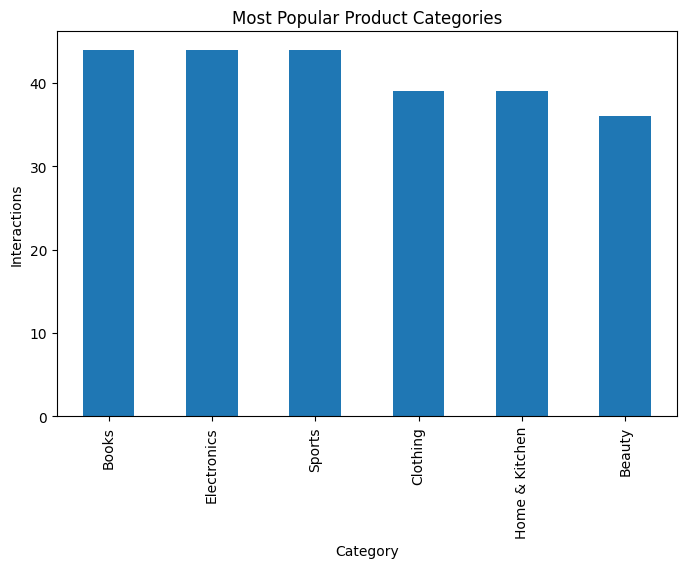

Conversion Rate: 29.44%


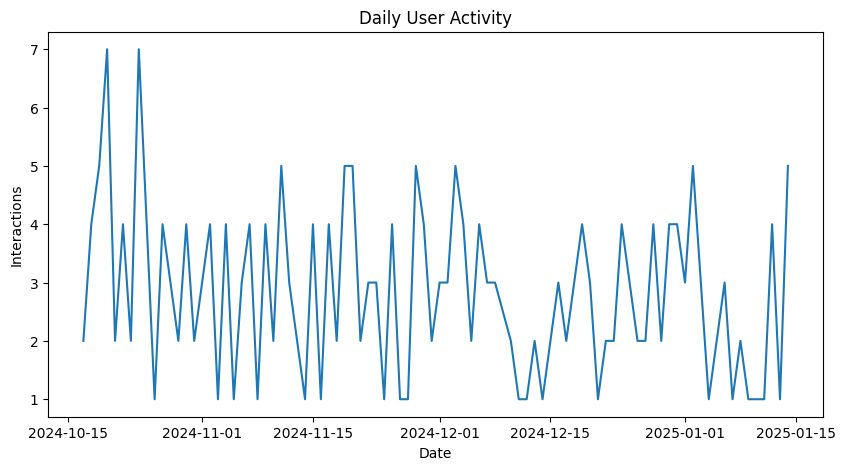

Product Category
Books             5285.54
Clothing          4461.69
Sports            3259.53
Electronics       3172.39
Home & Kitchen    1967.76
Beauty            1695.51
Name: Revenue, dtype: float64


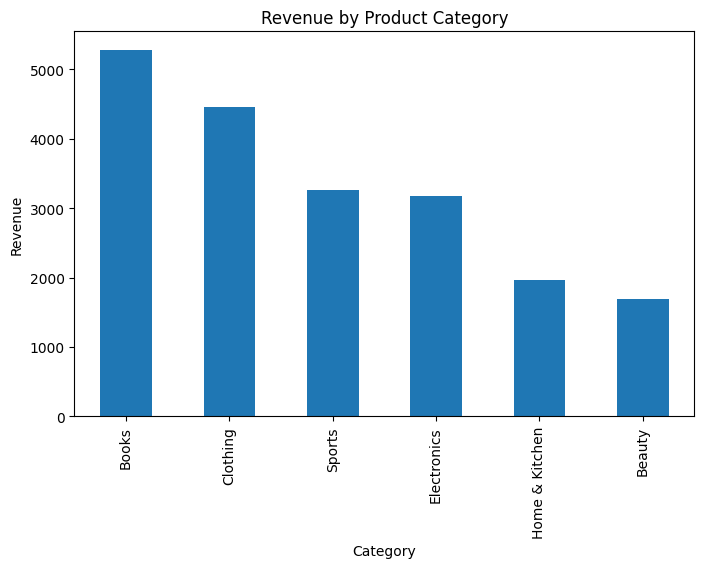

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("dataset.csv")
df["Revenue"] = df["Revenue"].fillna(0)
df = df.dropna(subset=["User ID", "Action"])

# Derive Useful Fields
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d-%m-%Y %H:%M")
# Date-based fields
df["Date"] = df["Timestamp"].dt.date
df["Week"] = df["Timestamp"].dt.isocalendar().week
df["Hour"] = df["Timestamp"].dt.hour

# Session duration
df = df.sort_values(by=["User ID", "Timestamp"])

df["Session_Duration"] = df.groupby("User ID")["Timestamp"].diff().dt.total_seconds() / 60

df["Session_Duration"] = df["Session_Duration"].fillna(0)

# Purchase flag
df["Is_Purchase"] = df["Action"].str.lower() == "purchased"

# Interaction count per user
df["Interaction_Count"] = df.groupby("User ID")["Action"].transform("count")

# Most Popular Product Categories Get all categories group by it's size in descending order
popular_categories = df.groupby("Product Category").size().sort_values(ascending=False)

print(popular_categories)
# Plot category
popular_categories.plot(kind="bar", figsize=(8,5))

plt.title("Most Popular Product Categories")
plt.xlabel("Category")
plt.ylabel("Interactions")

plt.show()

#Calculate the conversion rate (i.e., percentage of purchased actions out of total interactions).
total_interactions = len(df)

purchases = len(df[df["Action"] == "purchased"])

conversion_rate = (purchases / total_interactions) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")



# Visualise user behaviour trends over time (e.g., daily or weekly activity).
daily_activity = df.groupby("Date").size()
daily_activity.plot(figsize=(10,5))

plt.title("Daily User Activity")
plt.xlabel("Date")
plt.ylabel("Interactions")

plt.show()



revenue_by_category = df.groupby("Product Category")["Revenue"].sum().sort_values(ascending=False)
# Revenue by product
print(revenue_by_category)



revenue_by_category.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()